
# CS425 Diss-Poem Generator — Google Colab Training Notebook

This notebook implements a **three-source training/generation pipeline**:

1. **Sonnet dataset → poetic pretraining**
   - Teaches general poetic phrasing, line transitions, and literary structure.
2. **Diss dataset → style fine-tuning**
   - Adapts the same model toward diss-style vocabulary, direct address, punchlines, and confrontational phrasing.
3. **CSUdict / CMUdict-style pronunciation dictionary → rhyme and syllable control**
   - Used **after neural training** as a phonetic knowledge source rather than as ordinary language-model training text.

### Methodology

```text
SONNETS
   │
   ▼
Stage 1: GRU language-model pretraining
   │
   ▼
Poetry-aware model
   │
   ▼
DISS DATASET
   │
   ▼
Stage 2: diss-style fine-tuning
   │
   ▼
Diss-poem neural generator
   │
   ├── candidate line 1
   ├── candidate line 2
   ├── candidate line 3
   └── ...
          │
          ▼
CSUdict / CMUdict phonetic scoring
   ├── rhyme score
   └── syllable / meter score
          │
          ▼
Best candidate selected
```

The model used here is a **small character-level PyTorch GRU language model**, designed to be trainable on Google Colab without relying on an LLM API.

> **Before running:** In Colab, choose **Runtime → Change runtime type → GPU**. Run all cells, authorize the Google Drive mount, and upload `Sonnet-154.txt` and `diss.csv` only if they are missing from `My Drive/CS425/Datasets`.



## Part 0 — Install dependencies

### What this block does
Installs only missing libraries used by the notebook. Colab provides PyTorch; keep its CUDA-compatible build.

### Methodology
Google Colab already includes PyTorch in most runtimes, so the notebook **does not reinstall PyTorch**. This avoids accidentally replacing Colab's CUDA-compatible PyTorch build.

We install:
- `nltk` — optional CMU pronunciation dictionary fallback
- `pandas` — loading CSV datasets
- `matplotlib` — training curves
- `tqdm` — progress bars


In [49]:
"""
TRAINING PROCESS — PART 0: DEPENDENCY INSTALLATION

Install missing supporting packages without replacing Colab's PyTorch build.
"""
"""
ENVIRONMENT CHECK

Detect whether the notebook is running in Google Colab, import Colab-only
helpers when available, and verify the files needed by local training.
"""

from pathlib import Path
import importlib.util
import platform
import subprocess
import sys

IS_COLAB = (
    importlib.util.find_spec("google") is not None
    and importlib.util.find_spec("google.colab") is not None
)

if IS_COLAB:
    from google.colab import drive, files
else:
    drive = None
    files = None

NOTEBOOK_ROOT = Path.cwd()
LOCAL_DATA_DIR = NOTEBOOK_ROOT / "Datasets"
REQUIRED_LOCAL_FILES = {
    "sonnets": (
        LOCAL_DATA_DIR / "sonnets.txt",
        LOCAL_DATA_DIR / "cleaned" / "sonnets_cleaned.txt",
    ),
    "diss": (
        LOCAL_DATA_DIR / "diss.csv",
        LOCAL_DATA_DIR / "cleaned" / "diss_cleaned.csv",
    ),
}

print("Runtime:", "Google Colab" if IS_COLAB else "Local Jupyter/VS Code")
print("Python:", platform.python_version())
print("Working directory:", NOTEBOOK_ROOT)

if not IS_COLAB:
    missing = [
        name
        for name, paths in REQUIRED_LOCAL_FILES.items()
        if not any(path.is_file() for path in paths)
    ]
    if missing:
        print("WARNING: Missing local dataset(s):", ", ".join(missing))
        print("Expected them under:", LOCAL_DATA_DIR)
        print("You can update DATA_DIR in the environment setup cell or add the missing files.")
    else:
        print("Local dataset check: sonnets and diss data found.")
else:
    print("Colab dataset check: Google Drive will be mounted in the environment setup cell.")

packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "tqdm": "tqdm",
    "nltk": "nltk",
}
missing = [package for module, package in packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Supporting packages are already installed.")

if importlib.util.find_spec("torch") is None:
    raise RuntimeError("PyTorch is missing. Install PyTorch in the local environment before continuing.")


Runtime: Local Jupyter/VS Code
Python: 3.12.14
Working directory: /home/local/KLASS/david.yeo/Documents/Code/CS425-Project
Local dataset check: sonnets and diss data found.
Supporting packages are already installed.



## Part 1 — Imports, reproducibility, and GPU check

### What this block does
Imports libraries, fixes random seeds, checks whether CUDA is available, mounts Google Drive in Colab, and creates the working directories.

### Methodology
Datasets and cleaned copies live in `My Drive/CS425/Datasets`; checkpoints and plots stay in the Colab runtime until the final archive is downloaded. A fixed seed makes model initialization and dataset splitting more reproducible. Exact equality between GPU runs is not guaranteed, but this significantly reduces accidental variation.


In [50]:
"""
TRAINING PROCESS — PART 1: ENVIRONMENT SETUP

Purpose:
    Import libraries, set random seeds, select CPU/GPU,
    and create output/checkpoint directories.

Methodology:
    Use a fixed seed for reproducibility and automatically select
    CUDA when a Colab GPU runtime is available.
"""

from pathlib import Path
from collections import Counter
import json
import math
import random
import re
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_DIR = (
    Path("/content/diss_poem_project") if Path("/content").is_dir()
    else Path.cwd() / "diss_poem_project"
)

if IS_COLAB:
    drive.mount("/content/drive")
    # Colab exposes "My Drive" as "MyDrive" in the mounted filesystem.
    DATA_DIR = Path("/content/drive/MyDrive/CS425/Datasets")
else:
    # Local development uses the repository's Datasets folder.
    DATA_DIR = Path.cwd() / "Datasets"

CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
OUTPUT_DIR = PROJECT_DIR / "outputs"

for directory in [DATA_DIR, CHECKPOINT_DIR, OUTPUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Dataset folder:", DATA_DIR)

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not detected. Training will still work, but more slowly.")


Dataset folder: /home/local/KLASS/david.yeo/Documents/Code/CS425-Project/Datasets
PyTorch version: 2.14.0+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 2060



## Part 2 — Configuration

### What this block does
Defines dataset filenames within `My Drive/CS425/Datasets`, dataset-column names, model size, and training hyperparameters.

### Methodology
All important settings are centralized so experiments can be repeated consistently. For the project report, this cell also provides a convenient record of the chosen hyperparameters.

### Expected dataset format

**Sonnet file**: `sonnets.txt`
- Sonnets/poems separated by one or more blank lines, or consecutive 14-line sonnets.

**Diss file**: `diss.csv`
- One training sample per row.
- Required columns: `text` (paired diss) and `positive_traits` (the traits users describe about themselves). Existing `characteristics` roast labels may remain as metadata but are not used to condition the GRU.

**Pronunciation dictionary**: `csudict.dict`, `cmudict.dict`, or similar
- Expected CMU-style format such as:

```text
CAT  K AE1 T
HAT  HH AE1 T
ATTACK  AH0 T AE1 K
```

If no custom pronunciation dictionary is uploaded, the notebook can fall back to NLTK's CMUdict.


In [51]:
"""
TRAINING PROCESS — PART 2: CONFIGURATION

Purpose:
    Centralize file paths, preprocessing choices, model architecture,
    and training hyperparameters.

Methodology:
    Keeping these settings in one cell makes experimentation and
    reporting easier and reduces hidden changes between runs.
"""

# ------------------------------------------------------------------
# Dataset paths
# ------------------------------------------------------------------

SONNET_PATH = DATA_DIR / "sonnets.txt"
DISS_PATH = DATA_DIR / "diss.csv"
PRON_DICT_PATH = DATA_DIR / "csudict.dict"
CLEANED_DIR = DATA_DIR / "cleaned"
SONNET_CLEANED_PATH = CLEANED_DIR / "sonnets_cleaned.txt"
DISS_CLEANED_PATH = CLEANED_DIR / "diss_cleaned.csv"
FORCE_UPLOAD = False  # Set True to upload a custom dictionary or replace files.

# Change these if your diss CSV uses different column names.
DISS_TEXT_COLUMN = "text"
DISS_POSITIVE_TRAITS_COLUMN = "positive_traits"

# If the custom pronunciation dictionary is absent, use NLTK CMUdict.
USE_NLTK_CMUDICT_IF_MISSING = True

# ------------------------------------------------------------------
# Text preprocessing
# ------------------------------------------------------------------

LOWERCASE = True

# ------------------------------------------------------------------
# Sequence/model settings
# ------------------------------------------------------------------
#
# Tokenization is character-level (see Part 6), so SEQUENCE_LENGTH is
# measured in characters, not words.

SEQUENCE_LENGTH = 200
BATCH_SIZE = 64
USE_AMP = True  # Mixed precision on CUDA; full precision on CPU.
AMP_ENABLED = USE_AMP and DEVICE.type == "cuda"

EMBEDDING_DIM = 256
HIDDEN_DIM = 384
NUM_LAYERS = 3
DROPOUT = 0.2

# ------------------------------------------------------------------
# Training settings
# ------------------------------------------------------------------
#
# Training on CPU (no GPU). Character-level learning is efficient, so
# long runs are feasible; watch the VALIDATION loss/perplexity, not
# training loss, and let the best-checkpoint logic stop the effective
# fit once validation flattens (the small diss set can overfit).

VALIDATION_SPLIT = 0.10

SONNET_EPOCHS = 20
DISS_EPOCHS = 30
GENERIC_EXAMPLE_STRIDE = 4  # Train one generic prompt per four diss rows.
EARLY_STOP_PATIENCE = 8  # Stop a stage after this many epochs with no validation improvement.

SONNET_LEARNING_RATE = 3e-3
DISS_LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4
GRADIENT_CLIP_NORM = 1.0

# ------------------------------------------------------------------
# Generation settings
# ------------------------------------------------------------------
#
# MAX_TOKENS_PER_LINE is measured in characters (not words) because the
# tokenizer is character-level. Allow enough room for longer training
# lines; a capped line is trimmed to its last complete word.

GENERATION_TEMPERATURE = 0.9
TOP_K = 20
CANDIDATES_PER_LINE = 8
MAX_RHYME_CANDIDATES = 24  # Sample before repairing a line's end word.

# Line 1 is a cold start (only the trait prompt as context), so it is the
# most likely to garble. Sample it more conservatively and more broadly:
COLD_START_TEMPERATURE = 0.5  # Line 1 temperature (rest use GENERATION_TEMPERATURE).
COLD_START_CANDIDATES = 16    # Line 1 candidate count (rest use CANDIDATES_PER_LINE).

# Lexicon coherence filter: drop lines made mostly of words the
# pronunciation dictionary (123k+ real words) does not know.
LEXICON_PENALTY = 1.5                # Penalty per unit of unknown-word fraction.
MAX_UNKNOWN_WORD_FRACTION = 0.25     # Hard-drop a line above this unknown fraction.
TARGET_SYLLABLES = 10
MAX_TOKENS_PER_LINE = 80
MAX_CONTEXT_TOKENS = 256

print("Configuration loaded. Mixed precision:", AMP_ENABLED)


Configuration loaded. Mixed precision: True



## Part 3 — Upload datasets to Colab

### What this block does
Uses datasets already stored in `My Drive/CS425/Datasets`. If a required corpus is missing, it checks for a local `Datasets/` folder and then prompts for an upload, saving the file to Drive. You can also upload an optional pronunciation dictionary.

### Methodology
The notebook first checks `Datasets/` or the current directory for local files, then uses Colab’s upload dialog only for missing corpora. Set `FORCE_UPLOAD = True` in Part 2 to upload an optional dictionary or replace files.

Cleaned files named `*_cleaned.txt` or `*_cleaned.csv` are stored in `My Drive/CS425/Datasets/cleaned/` and take priority over raw files in the same Drive folder.

If your files already exist in the Drive folder, this cell skips the upload prompt.

> For larger datasets, you may instead mount Google Drive and update the paths in **Part 2**.


In [52]:
"""
TRAINING PROCESS — PART 3: DATASET UPLOAD

Prompt only when a required corpus is missing. Accept raw and _cleaned files.
"""

import shutil

# Use files already present in the runtime, including a cloned project folder.
candidate_dirs = [
    Path.cwd() / "Datasets",
    Path.cwd() / "CS425-Project" / "Datasets",
    Path.cwd(),
]


def copy_available(relative_name, destination):
    for directory in candidate_dirs:
        source = directory / relative_name
        if source.is_file():
            if source.resolve() != destination.resolve():
                destination.parent.mkdir(parents=True, exist_ok=True)
                shutil.copyfile(source, destination)
            print(f"Found {source} -> {destination}")
            return True
    return False


if not (SONNET_CLEANED_PATH.exists() or SONNET_PATH.exists()):
    copy_available("cleaned/sonnets_cleaned.txt", SONNET_CLEANED_PATH)
    if not SONNET_CLEANED_PATH.exists():
        copy_available("Sonnet-154.txt", SONNET_PATH) or copy_available("sonnets.txt", SONNET_PATH)
if not (DISS_CLEANED_PATH.exists() or DISS_PATH.exists()):
    copy_available("cleaned/diss_cleaned.csv", DISS_CLEANED_PATH)
    if not DISS_CLEANED_PATH.exists():
        copy_available("diss.csv", DISS_PATH)
if not PRON_DICT_PATH.exists():
    copy_available("csudict.dict", PRON_DICT_PATH) or copy_available("cmudict.dict", PRON_DICT_PATH)

missing = []
if not (SONNET_PATH.exists() or SONNET_CLEANED_PATH.exists()):
    missing.append("Sonnet-154.txt or sonnets_cleaned.txt")
if not (DISS_PATH.exists() or DISS_CLEANED_PATH.exists()):
    missing.append("diss.csv or diss_cleaned.csv")

if missing or FORCE_UPLOAD:
    if missing:
        print("Upload these missing datasets:", ", ".join(missing))
    else:
        print("Optional upload requested; choose files to add or replace.")
    if not IS_COLAB:
        raise RuntimeError(
            "Place the missing datasets in the configured data folder "
            "or run this cell in Google Colab to upload them."
        )

    uploaded = files.upload()

    for filename, data in uploaded.items():
        source_name = Path(filename).name.lower()

        if source_name.endswith(".txt") and "sonnet" in source_name:
            destination = (
                SONNET_CLEANED_PATH if source_name.endswith("_cleaned.txt")
                else SONNET_PATH
            )
        elif source_name.endswith(".csv") and "diss" in source_name:
            destination = (
                DISS_CLEANED_PATH if source_name.endswith("_cleaned.csv")
                else DISS_PATH
            )
        elif (
            source_name.endswith(".dict")
            or "cmudict" in source_name
            or "csudict" in source_name
        ):
            destination = PRON_DICT_PATH
        else:
            destination = DATA_DIR / Path(filename).name

        destination.parent.mkdir(parents=True, exist_ok=True)
        destination.write_bytes(data)
        print(f"Saved {filename} -> {destination}")
else:
    print("Sonnet and diss datasets found; skipping upload.")


Sonnet and diss datasets found; skipping upload.



## Part 4 — Load and clean the datasets

### What this block does
Loads both text corpora and applies basic normalization. The first run saves `sonnets_cleaned.txt` and `diss_cleaned.csv` in `My Drive/CS425/Datasets/cleaned/`. Later runs load each cleaned file directly when it exists, even if the raw file is absent.

### Methodology
The sonnet and diss datasets are deliberately kept **separate** because they are used in different training stages.
Sonnet files without blank-line separators are grouped into 14-line samples.

Line breaks are preserved because line structure matters for poetry. Excess whitespace is removed, and optional lowercasing reduces vocabulary size for a relatively small model. The diss CSV pairs each diss with a positive self-description in `positive_traits`. Cleaning keeps those columns and any extra metadata, including the existing negative `characteristics` labels. Stage 2 conditions each diss on `positive_traits` only.

Delete an individual `_cleaned` file when its raw dataset or preprocessing settings change and you want to regenerate it.


In [53]:

"""
TRAINING PROCESS — PART 4: DATA LOADING AND CLEANING

Purpose:
    Read the sonnet and diss corpora into separate Python lists.

Methodology:
    Preserve poem line boundaries while removing unnecessary
    whitespace. Keep the two corpora separate for staged training.
"""

def clean_text(text: str, lowercase: bool = True) -> str:
    """
    Normalize one poem/diss sample while preserving line boundaries.
    """
    text = str(text).replace("\r\n", "\n").replace("\r", "\n")

    cleaned_lines = []
    for line in text.split("\n"):
        line = re.sub(r"\s+", " ", line).strip()
        if line:
            cleaned_lines.append(line)

    text = "\n".join(cleaned_lines)

    if lowercase:
        text = text.lower()

    return text


def split_sonnet_samples(raw_text: str):
    """
    Use blank-line poem boundaries, or 14-line sonnets if none exist.
    """
    samples = [sample for sample in re.split(r"\n\s*\n", raw_text) if sample.strip()]

    if len(samples) == 1:
        lines = [line for line in raw_text.splitlines() if line.strip()]
        if len(lines) >= 28:
            print("No blank-line sonnet separators found; grouping every 14 lines.")
            if len(lines) % 14:
                print("WARNING: Sonnet line count is not divisible by 14; check poem boundaries.")
            return ["\n".join(lines[index:index + 14]) for index in range(0, len(lines), 14)]

    return samples


def load_sonnet_txt(path: Path, cleaned_path: Path):
    """
    Load cached poems when available; otherwise clean and save the raw poems.
    """
    if cleaned_path.exists():
        source_path = cleaned_path
        print(f"Using cleaned sonnet dataset: {cleaned_path}")
    else:
        if not path.exists():
            raise FileNotFoundError(
                f"Sonnet file not found: {path}\n"
                f"No cleaned dataset found at: {cleaned_path}\n"
                "Upload a file in Part 3 or change SONNET_PATH."
            )
        source_path = path

    raw_text = source_path.read_text(encoding="utf-8", errors="ignore")
    samples = split_sonnet_samples(raw_text)

    if source_path == cleaned_path:
        return samples

    samples = [clean_text(sample, lowercase=LOWERCASE) for sample in samples]
    cleaned_path.parent.mkdir(parents=True, exist_ok=True)
    cleaned_path.write_text("\n\n".join(samples), encoding="utf-8")
    print(f"Saved cleaned sonnet dataset: {cleaned_path}")
    return samples


def load_diss_csv(path: Path, text_column: str, positive_column: str,
                  cleaned_path: Path):
    """Load positive-traits/diss pairs, reusing a compatible cleaned CSV."""
    required = {text_column, positive_column}
    if cleaned_path.exists():
        source_path = cleaned_path
        df = pd.read_csv(source_path)
        if not required.issubset(df.columns):
            if not path.exists():
                raise ValueError(
                    f"Cached diss CSV lacks columns {sorted(required - set(df.columns))}. "
                    f"Add the updated raw CSV at {path} or replace {cleaned_path}."
                )
            print("Cached diss CSV lacks positive_traits; rebuilding from raw CSV.")
            source_path = path
            df = pd.read_csv(source_path)
        else:
            print(f"Using cleaned diss dataset: {cleaned_path}")
    else:
        if not path.exists():
            raise FileNotFoundError(
                f"Diss CSV not found: {path}\n"
                f"No cleaned dataset found at: {cleaned_path}\n"
                "Upload a file in Part 3 or change DISS_PATH."
            )
        source_path = path
        df = pd.read_csv(source_path)

    missing = required - set(df.columns)
    if missing:
        raise ValueError(
            f"Columns {sorted(missing)} not found in {source_path}. "
            "Add positive_traits to each diss row before running Stage 2. "
            f"Available columns: {list(df.columns)}"
        )

    df = df.dropna(subset=[text_column, positive_column]).copy()
    if source_path != cleaned_path:
        df[text_column] = df[text_column].map(
            lambda sample: clean_text(sample, lowercase=LOWERCASE)
        )
        df[positive_column] = df[positive_column].map(
            lambda traits: clean_text(traits, lowercase=LOWERCASE).replace("\n", " ")
        )
        df = df[df[text_column].ne("") & df[positive_column].ne("")]
        cleaned_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(cleaned_path, index=False)
        print(f"Saved cleaned diss dataset: {cleaned_path}")

    pairs = [
        {"text": str(text), "positive_traits": str(positive_traits)}
        for text, positive_traits in zip(df[text_column], df[positive_column])
        if str(text).strip() and str(positive_traits).strip()
    ]
    if not pairs:
        raise ValueError(f"No usable positive_traits/diss pairs in {source_path}")
    return pairs

sonnet_samples = load_sonnet_txt(SONNET_PATH, SONNET_CLEANED_PATH)
diss_samples = load_diss_csv(
    DISS_PATH, DISS_TEXT_COLUMN, DISS_POSITIVE_TRAITS_COLUMN, DISS_CLEANED_PATH
)

print(f"Sonnet samples: {len(sonnet_samples):,}")
print(f"Diss samples:    {len(diss_samples):,}")

print("\n--- Example sonnet sample ---")
print(sonnet_samples[0][:600])

print("\n--- Example diss sample ---")
print("Positive traits:", diss_samples[0]["positive_traits"])
print("Diss:", diss_samples[0]["text"][:600])


Using cleaned sonnet dataset: /home/local/KLASS/david.yeo/Documents/Code/CS425-Project/Datasets/cleaned/sonnets_cleaned.txt
Using cleaned diss dataset: /home/local/KLASS/david.yeo/Documents/Code/CS425-Project/Datasets/cleaned/diss_cleaned.csv
Sonnet samples: 154
Diss samples:    3,867

--- Example sonnet sample ---
from fairest creatures we desire increase,
that thereby beauty’s rose might never die,
but as the riper should by time decrease,
his tender heir mught bear his memeory:
but thou, contracted to thine own bright eyes,
feed’st thy light’st flame with self-substantial fuel,
making a famine where abundance lies,
thyself thy foe, to thy sweet self too cruel.
thou that art now the world’s fresh ornament
and only herald to the gaudy spring,
within thine own bud buriest thy content
and, tender churl, makest waste in niggarding.
pity the world, or else this glutton be,
to eat the world’s due, by the gra

--- Example diss sample ---
Positive traits: confident, proud, accomplished, self


## Part 5 — Split train and validation data at the **sample level**

### What this block does
Separates complete poems/diss samples into training and validation subsets **before** creating overlapping token windows.

### Methodology
This avoids a common form of data leakage. If we created overlapping chunks first and then randomly split the chunks, nearly identical text windows from the same poem could appear in both training and validation data.

Instead:

```text
Whole poems/samples
       │
       ├── training samples
       └── validation samples
              │
              ▼
        token windows created
```


In [54]:

"""
TRAINING PROCESS — PART 5: SAMPLE-LEVEL TRAIN/VALIDATION SPLIT

Purpose:
    Split complete source samples before token chunking.

Methodology:
    Prevent overlapping windows from the same original sample from
    leaking into both training and validation sets.
"""

def split_samples(samples, validation_split=0.10, seed=42):
    """
    Deterministically shuffle and split a list of complete samples.
    """
    samples = list(samples)

    rng = random.Random(seed)
    rng.shuffle(samples)

    if len(samples) < 2:
        raise ValueError("Need at least 2 samples for train/validation splitting.")

    validation_size = max(1, int(len(samples) * validation_split))
    validation_size = min(validation_size, len(samples) - 1)

    validation_samples = samples[:validation_size]
    training_samples = samples[validation_size:]

    return training_samples, validation_samples


sonnet_train_samples, sonnet_val_samples = split_samples(
    sonnet_samples,
    validation_split=VALIDATION_SPLIT,
    seed=SEED,
)

diss_train_samples, diss_val_samples = split_samples(
    diss_samples,
    validation_split=VALIDATION_SPLIT,
    seed=SEED,
)

print("Sonnet train / val:", len(sonnet_train_samples), "/", len(sonnet_val_samples))
print("Diss train / val:   ", len(diss_train_samples), "/", len(diss_val_samples))


Sonnet train / val: 139 / 15
Diss train / val:    3481 / 386



## Part 6 — Build the tokenizer and shared vocabulary

### What this block does
Creates a character-level tokenizer and builds a **shared vocabulary** from the sonnet and diss corpora.

### Methodology
The vocabulary is shared because the same neural network is used across both stages.

Special tokens:
- `<PAD>` — padding
- `<BOS>` — beginning of sequence
- `<EOS>` — end of sequence
- `<NL>` — poem line break
- `<SONNET>` — identifies sonnet-style input
- `<DISS>` — identifies diss-style input
- `<TRAITS>` — starts the positive self-description prompt
- `<RESPONSE>` — starts the target diss

The explicit `<NL>` token helps the model learn where poetic lines end.


In [55]:
"""
TRAINING PROCESS — PART 6: TOKENIZATION AND VOCABULARY

Purpose:
    Convert raw text to tokens and create a shared vocabulary.

Methodology:
    Use a character-level tokenizer: each character is one token.

    Line breaks and style/structure are still exposed explicitly with
    dedicated tokens so the small GRU can learn line endings and corpus
    identity:
    - `<NL>`    — poem line break (replaces the space character, so a
                  line has no trailing space)
    - `<BOS>` / `<EOS>` — sequence boundaries
    - `<SONNET>` / `<DISS>` — corpus identity
    - `<TRAITS>` / `<RESPONSE>` — trait-prompt and answer boundaries
"""

SPECIAL_TOKENS = [
    "<PAD>",
    "<BOS>",
    "<EOS>",
    "<NL>",
    "<SONNET>",
    "<DISS>",
    "<TRAITS>",
    "<RESPONSE>",
]

# Characters that are treated as their own tokens.
SINGLE_TOKEN_CHARS = set("\n ,.!?;:()[]{}-")


class CharTokenizer:
    """
    Character-level tokenizer. Each printable character is one token;
    structural characters (newline, space, punctuation) are mapped to
    their own ids, and line breaks use the explicit <NL> token.
    """

    def __init__(self):
        self.token_to_id = {}
        self.id_to_token = {}

    def fit(self, texts):
        char_counts = Counter()
        structural = set()

        for text in texts:
            for ch in str(text):
                if ch in SINGLE_TOKEN_CHARS:
                    structural.add(ch)
                elif ch.isprintable() and not ch.isspace():
                    char_counts[ch] += 1

        # Structural tokens first (deterministic), then frequent letters.
        vocabulary = list(SPECIAL_TOKENS)
        for ch in sorted(structural):
            vocabulary.append(ch)
        for ch, _ in sorted(
            char_counts.items(), key=lambda item: (-item[1], item[0])
        ):
            vocabulary.append(ch)

        self.token_to_id = {token: index for index, token in enumerate(vocabulary)}
        self.id_to_token = {index: token for token, index in self.token_to_id.items()}

    def tokenize(self, text):
        tokens = []
        for ch in str(text):
            if ch == "\n":
                tokens.append("<NL>")
            elif ch in SINGLE_TOKEN_CHARS:
                tokens.append(ch)
            elif ch.isprintable():
                tokens.append(ch)
            # Ignore other whitespace (already collapsed upstream).
        return tokens

    def encode(self, text, style_token=None, add_bos=True, add_eos=True):
        ids = []
        if add_bos:
            ids.append(self.token_to_id["<BOS>"])
        if style_token is not None:
            ids.append(self.token_to_id[style_token])
        for token in self.tokenize(text):
            ids.append(self.token_to_id[token])
        if add_eos:
            ids.append(self.token_to_id["<EOS>"])
        return ids

    def decode(self, ids):
        tokens = [self.id_to_token[int(index)] for index in ids]
        output = []
        for token in tokens:
            if token in {
                "<PAD>", "<BOS>", "<EOS>",
                "<SONNET>", "<DISS>", "<TRAITS>", "<RESPONSE>",
            }:
                continue
            if token == "<NL>":
                output.append("\n")
            else:
                output.append(token)
        text = "".join(output)
        # Trim spaces that sit against a line break.
        text = text.replace(" \n", "\n").replace("\n ", "\n")
        return text.strip()

    def __len__(self):
        return len(self.token_to_id)


tokenizer = CharTokenizer()

# Vocabulary is built from the complete available corpora.
tokenizer.fit(
    sonnet_samples
    + [pair["positive_traits"] for pair in diss_samples]
    + [pair["text"] for pair in diss_samples]
)

print("Vocabulary size (characters):", len(tokenizer))
print("Example chars:", tokenizer.tokenize("you talk big"))
print("Decoded check:", tokenizer.decode(
    tokenizer.encode("you talk big,\nbut your rhyme falls flat.")
))

# Save the vocabulary for reproducibility.
with open(OUTPUT_DIR / "vocabulary.json", "w", encoding="utf-8") as f:
    json.dump(tokenizer.token_to_id, f, ensure_ascii=False, indent=2)


Vocabulary size (characters): 55
Example chars: ['y', 'o', 'u', ' ', 't', 'a', 'l', 'k', ' ', 'b', 'i', 'g']
Decoded check: you talk big,
but your rhyme falls flat.



## Part 7 — Convert text into next-token prediction examples

### What this block does
Turns each poem/sample into fixed-length training windows.

### Methodology
The network is trained autoregressively: given the current tokens, it predicts the next token.

Sonnet training predicts the next poem token. Diss training uses each CSV pair:

```text
Input:   <BOS> <DISS> <TRAITS> confident <RESPONSE> you talk big
Target:  [ignored prompt tokens] you talk big but
```

Only diss text contributes to the diss-stage loss. Every fourth diss row also trains with an empty `<TRAITS>` prompt so the GRU can generate a generic diss when a user query matches no training trait.

Long samples are divided into overlapping windows to create more training examples while preserving local context.


In [56]:

"""
TRAINING PROCESS — PART 7: AUTOREGRESSIVE DATASET CREATION

Purpose:
    Convert samples into fixed-length (input, target) pairs.

Methodology:
    Use next-token prediction with overlapping windows.
    Training/validation separation already happened at the original
    sample level in Part 5.
"""

class CorpusLMDataset(Dataset):
    """
    Fixed-length autoregressive language-model dataset.
    """

    def __init__(
        self,
        samples,
        tokenizer,
        style_token,
        sequence_length=64,
        stride=None
    ):
        self.examples = []

        if stride is None:
            stride = max(1, (sequence_length - 2) // 2)

        bos_id = tokenizer.token_to_id["<BOS>"]
        eos_id = tokenizer.token_to_id["<EOS>"]
        pad_id = tokenizer.token_to_id["<PAD>"]
        style_id = tokenizer.token_to_id[style_token]

        # Two positions are reserved for BOS and the style token.
        max_content_length = sequence_length - 2

        for sample in samples:
            content = tokenizer.encode(
                sample,
                add_bos=False,
                add_eos=False
            )

            if not content:
                continue

            for start in range(0, len(content), stride):
                chunk = content[start:start + max_content_length]

                if not chunk:
                    continue

                sequence = [bos_id, style_id, *chunk]

                # Add EOS when the current chunk reaches the end
                # of the original source sample.
                if start + max_content_length >= len(content):
                    sequence.append(eos_id)

                # Need sequence_length + 1 tokens so that shifting
                # produces an input and a same-length target.
                desired_length = sequence_length + 1

                if len(sequence) < desired_length:
                    sequence += [pad_id] * (desired_length - len(sequence))
                else:
                    sequence = sequence[:desired_length]

                x = torch.tensor(sequence[:-1], dtype=torch.long)
                y = torch.tensor(sequence[1:], dtype=torch.long)

                self.examples.append((x, y))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, index):
        return self.examples[index]


class ConditionalDissDataset(Dataset):
    """Predict diss text from matched traits or a generic empty prompt."""

    def __init__(self, pairs, tokenizer, sequence_length=64,
                 generic_stride=GENERIC_EXAMPLE_STRIDE):
        self.examples = []
        ids = tokenizer.token_to_id
        pad_id = ids["<PAD>"]
        eos_id = ids["<EOS>"]
        generic_prefix = [
            ids["<BOS>"], ids["<DISS>"], ids["<TRAITS>"], ids["<RESPONSE>"]
        ]

        for pair_index, pair in enumerate(pairs):
            trait_ids = tokenizer.encode(
                pair["positive_traits"], add_bos=False, add_eos=False
            )
            diss_ids = tokenizer.encode(
                pair["text"], add_bos=False, add_eos=False
            )
            conditional_prefix = [
                ids["<BOS>"], ids["<DISS>"], ids["<TRAITS>"],
                *trait_ids, ids["<RESPONSE>"]
            ]
            prefixes = [conditional_prefix]
            if generic_stride > 0 and pair_index % generic_stride == 0:
                prefixes.append(generic_prefix)

            for prefix in prefixes:
                max_diss_tokens = sequence_length - len(prefix)
                if max_diss_tokens < 1:
                    raise ValueError(
                        "Positive traits prompt is too long for SEQUENCE_LENGTH; "
                        "increase it or shorten positive_traits."
                    )

                stride = max(1, max_diss_tokens // 2)
                for start in range(0, len(diss_ids), stride):
                    chunk = diss_ids[start:start + max_diss_tokens]
                    if not chunk:
                        continue
                    sequence = [*prefix, *chunk]
                    if start + max_diss_tokens >= len(diss_ids):
                        sequence.append(eos_id)
                    sequence = sequence[:sequence_length + 1]
                    sequence += [pad_id] * (sequence_length + 1 - len(sequence))

                    x = torch.tensor(sequence[:-1], dtype=torch.long)
                    y = torch.tensor(sequence[1:], dtype=torch.long)
                    # Prompt tokens provide context; only diss tokens are targets.
                    y[:len(prefix) - 1] = pad_id
                    self.examples.append((x, y))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, index):
        return self.examples[index]

sonnet_train_dataset = CorpusLMDataset(
    sonnet_train_samples,
    tokenizer,
    style_token="<SONNET>",
    sequence_length=SEQUENCE_LENGTH
)

sonnet_val_dataset = CorpusLMDataset(
    sonnet_val_samples,
    tokenizer,
    style_token="<SONNET>",
    sequence_length=SEQUENCE_LENGTH
)

diss_train_dataset = ConditionalDissDataset(
    diss_train_samples, tokenizer, sequence_length=SEQUENCE_LENGTH
)

diss_val_dataset = ConditionalDissDataset(
    diss_val_samples, tokenizer, sequence_length=SEQUENCE_LENGTH
)

print("Sonnet train sequences:", len(sonnet_train_dataset))
print("Sonnet val sequences:  ", len(sonnet_val_dataset))
print("Diss train sequences:   ", len(diss_train_dataset))
print("Diss val sequences:     ", len(diss_val_dataset))


Sonnet train sequences: 937
Sonnet val sequences:   101
Diss train sequences:    8850
Diss val sequences:      997



## Part 8 — Define the GRU language model

### What this block does
Defines the neural network that learns both poetry and diss-style text.

### Methodology

```text
Token IDs
   ↓
Embedding layer
   ↓
Stacked GRU
   ↓
Linear output layer
   ↓
Probability distribution over the next token
```

A GRU is used because it is a compact recurrent architecture that is practical to train from scratch on Colab. It also makes the staged-transfer-learning methodology easy to explain.


In [57]:

"""
TRAINING PROCESS — PART 8: MODEL ARCHITECTURE

Purpose:
    Define a compact character-level GRU language model.

Methodology:
    Learn token embeddings, process sequential context with stacked
    GRUs, and project each hidden state to vocabulary logits.
"""

class DissPoemGRU(nn.Module):
    """
    Small recurrent language model for poetry/diss generation.
    """

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_layers,
        dropout,
        pad_id
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id
        )

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )

        self.output = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_ids, hidden=None):
        embedded = self.embedding(input_ids)
        sequence_output, hidden = self.gru(embedded, hidden)
        logits = self.output(sequence_output)

        return logits, hidden


model = DissPoemGRU(
    vocab_size=len(tokenizer),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    pad_id=tokenizer.token_to_id["<PAD>"]
).to(DEVICE)

parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nTrainable parameters: {parameter_count:,}")


DissPoemGRU(
  (embedding): Embedding(55, 256, padding_idx=0)
  (gru): GRU(256, 384, num_layers=3, batch_first=True, dropout=0.2)
  (output): Linear(in_features=384, out_features=55, bias=True)
)

Trainable parameters: 2,548,919



## Part 9 — Training and validation utilities

### What this block does
Defines reusable functions for:
- mini-batch training with optional CUDA mixed precision
- validation
- perplexity calculation
- checkpoint saving
- early restoration of the best epoch
- plotting loss curves

### Methodology
The loss is **cross-entropy over the next token**. Padding positions are ignored.

The best checkpoint is selected by **validation loss**, not training loss, to reduce the risk of keeping an overfit final epoch.


In [58]:
"""
TRAINING PROCESS — PART 9: TRAINING UTILITIES

Train with optional CUDA mixed precision, clipped gradients, and the best
validation checkpoint. Keep epoch losses on the device until the epoch ends.
"""

def make_loader(dataset, shuffle):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,  # Small in-memory dataset: avoid worker startup overhead.
        pin_memory=DEVICE.type == "cuda",
    )


def run_training_epoch(model, dataloader, optimizer, pad_id, scaler):
    model.train()
    total_loss = torch.zeros((), device=DEVICE)
    total_tokens = torch.zeros((), dtype=torch.long, device=DEVICE)

    for x, y in tqdm(dataloader, leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
            logits, _ = model(x)
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                y.reshape(-1),
                ignore_index=pad_id,
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        token_count = (y != pad_id).sum()
        total_loss += loss.detach() * token_count
        total_tokens += token_count

    return (total_loss / total_tokens).item()


@torch.no_grad()
def run_validation(model, dataloader, pad_id):
    model.eval()
    total_loss = torch.zeros((), device=DEVICE)
    total_tokens = torch.zeros((), dtype=torch.long, device=DEVICE)

    for x, y in dataloader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with torch.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
            logits, _ = model(x)
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                y.reshape(-1),
                ignore_index=pad_id,
            )

        token_count = (y != pad_id).sum()
        total_loss += loss.detach() * token_count
        total_tokens += token_count

    return (total_loss / total_tokens).item()


def fit_stage(model, train_dataset, val_dataset, epochs, learning_rate, stage_name):
    if not train_dataset or not val_dataset:
        raise ValueError(f"{stage_name} needs non-empty training and validation sets.")
    if epochs < 1:
        raise ValueError(f"{stage_name} epochs must be at least 1.")

    train_loader = make_loader(train_dataset, shuffle=True)
    val_loader = make_loader(val_dataset, shuffle=False)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=learning_rate, weight_decay=WEIGHT_DECAY
    )
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    pad_id = tokenizer.token_to_id["<PAD>"]
    best_val_loss = float("inf")
    best_epoch = 0
    best_checkpoint = CHECKPOINT_DIR / f"{stage_name}_best.pt"
    history = {"train_loss": [], "val_loss": [], "val_perplexity": []}

    for epoch in range(1, epochs + 1):
        train_loss = run_training_epoch(
            model, train_loader, optimizer, pad_id, scaler
        )
        val_loss = run_validation(model, val_loader, pad_id)
        val_perplexity = math.exp(min(val_loss, 20))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_perplexity"].append(val_perplexity)

        print(
            f"[{stage_name}] Epoch {epoch:02d}/{epochs} | "
            f"train loss={train_loss:.4f} | "
            f"val loss={val_loss:.4f} | "
            f"val perplexity={val_perplexity:.2f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "stage_name": stage_name,
                    "epoch": epoch,
                    "validation_loss": val_loss,
                    "config": {
                        "embedding_dim": EMBEDDING_DIM,
                        "hidden_dim": HIDDEN_DIM,
                        "num_layers": NUM_LAYERS,
                        "dropout": DROPOUT,
                        "sequence_length": SEQUENCE_LENGTH,
                    },
                },
                best_checkpoint,
            )
        elif epoch - best_epoch >= EARLY_STOP_PATIENCE:
            print(
                f"[{stage_name}] Early stop: no validation improvement for "
                f"{EARLY_STOP_PATIENCE} epochs (best at epoch {best_epoch})."
            )
            break

    checkpoint = torch.load(best_checkpoint, map_location=DEVICE, weights_only=True)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(
        f"Restored best {stage_name} checkpoint "
        f"(epoch {checkpoint['epoch']}, val loss={checkpoint['validation_loss']:.4f})."
    )
    return history


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], marker="o", label="Training loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()
    plt.close()



# Stage 1 — Sonnet pretraining

## Part 10 — Train first on sonnets

### What this block does
Trains the GRU on the sonnet corpus.

### Methodology
This is a form of **domain pretraining / transfer learning**. The model first learns general poetic patterns before seeing the more specialized diss data.

Expected learning includes:
- poetic word sequences
- line transitions
- literary phrasing
- punctuation and line-break patterns

The model is **not reset** after this stage; the learned weights become the starting point for diss fine-tuning.


STAGE 1: SONNET PRETRAINING


  0%|          | 0/15 [00:00<?, ?it/s]

[sonnet] Epoch 01/20 | train loss=3.1956 | val loss=2.7781 | val perplexity=16.09


  0%|          | 0/15 [00:00<?, ?it/s]

[sonnet] Epoch 02/20 | train loss=2.5490 | val loss=2.3329 | val perplexity=10.31


...

[sonnet] Epoch 18/20 | train loss=1.2312 | val loss=1.5649 | val perplexity=4.78


  0%|          | 0/15 [00:00<?, ?it/s]

[sonnet] Epoch 19/20 | train loss=1.1935 | val loss=1.5742 | val perplexity=4.83


  0%|          | 0/15 [00:00<?, ?it/s]

[sonnet] Epoch 20/20 | train loss=1.1585 | val loss=1.6028 | val perplexity=4.97
Restored best sonnet checkpoint (epoch 14, val loss=1.5403).


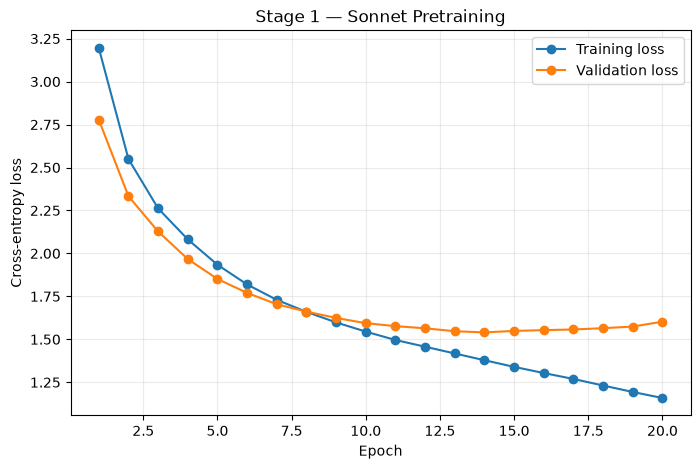

In [59]:

"""
TRAINING PROCESS — PART 10: STAGE 1 — SONNET PRETRAINING

Purpose:
    Train the base GRU on poetic text before specialization.

Methodology:
    Use sonnet next-token prediction to initialize the neural weights
    with poetry-oriented language patterns.
"""

print("=" * 70)
print("STAGE 1: SONNET PRETRAINING")
print("=" * 70)

sonnet_history = fit_stage(
    model=model,
    train_dataset=sonnet_train_dataset,
    val_dataset=sonnet_val_dataset,
    epochs=SONNET_EPOCHS,
    learning_rate=SONNET_LEARNING_RATE,
    stage_name="sonnet"
)

plot_history(
    sonnet_history,
    "Stage 1 — Sonnet Pretraining"
)



# Stage 2 — Diss fine-tuning

## Part 11 — Fine-tune the same model on the diss dataset

### What this block does
Continues training from the best sonnet checkpoint using positive_traits/diss pairs.

### Methodology
The diss stage uses a **smaller learning rate** than sonnet pretraining so the model can adapt to the new style without immediately overwriting all previously learned poetic structure.

The GRU reads each positive self-description as a prompt, then predicts only its paired diss text. Some rows also use an empty traits prompt, teaching the generic fallback. Negative roast labels remain optional CSV metadata.

Expected specialization:
- diss vocabulary
- direct-address phrasing
- setup/punchline patterns
- sharper rhetorical language


STAGE 2: DISS FINE-TUNING


  0%|          | 0/139 [00:00<?, ?it/s]

[diss] Epoch 01/30 | train loss=1.3754 | val loss=1.0686 | val perplexity=2.91


  0%|          | 0/139 [00:00<?, ?it/s]

[diss] Epoch 02/30 | train loss=1.0274 | val loss=0.9082 | val perplexity=2.48


...

[diss] Epoch 19/30 | train loss=0.4915 | val loss=0.7269 | val perplexity=2.07


  0%|          | 0/139 [00:00<?, ?it/s]

[diss] Epoch 20/30 | train loss=0.4831 | val loss=0.7227 | val perplexity=2.06


  0%|          | 0/139 [00:00<?, ?it/s]

[diss] Epoch 21/30 | train loss=0.4722 | val loss=0.7215 | val perplexity=2.06
[diss] Early stop: no validation improvement for 8 epochs (best at epoch 13).
Restored best diss checkpoint (epoch 13, val loss=0.7131).


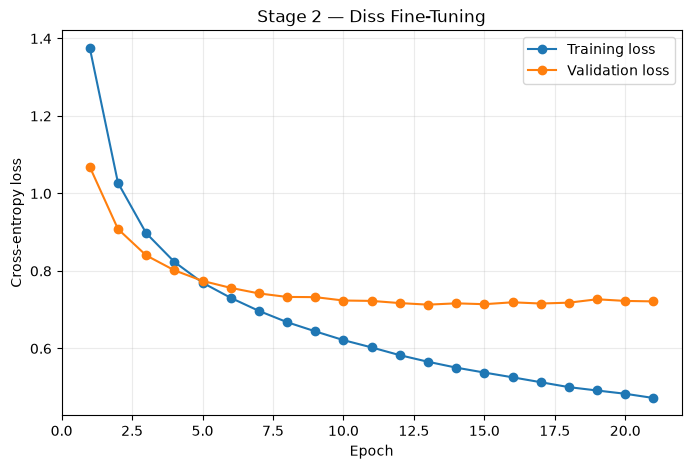

Final model saved to: /home/local/KLASS/david.yeo/Documents/Code/CS425-Project/diss_poem_project/checkpoints/diss_poem_final.pt


In [60]:

"""
TRAINING PROCESS — PART 11: STAGE 2 — DISS FINE-TUNING

Purpose:
    Specialize the poetry-aware model on diss-style text.

Methodology:
    Continue training the same network with a lower learning rate.
    This preserves useful poetic features while adapting its output
    distribution to the diss corpus.
"""

print("=" * 70)
print("STAGE 2: DISS FINE-TUNING")
print("=" * 70)

diss_history = fit_stage(
    model=model,
    train_dataset=diss_train_dataset,
    val_dataset=diss_val_dataset,
    epochs=DISS_EPOCHS,
    learning_rate=DISS_LEARNING_RATE,
    stage_name="diss"
)

plot_history(
    diss_history,
    "Stage 2 — Diss Fine-Tuning"
)

FINAL_MODEL_PATH = CHECKPOINT_DIR / "diss_poem_final.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "token_to_id": tokenizer.token_to_id,
        "config": {
            "embedding_dim": EMBEDDING_DIM,
            "hidden_dim": HIDDEN_DIM,
            "num_layers": NUM_LAYERS,
            "dropout": DROPOUT,
            "sequence_length": SEQUENCE_LENGTH,
        },
    },
    FINAL_MODEL_PATH
)

print("Final model saved to:", FINAL_MODEL_PATH)



# Stage 3 — Pronunciation-based rhyme and meter control

## Part 12 — Load CSUdict / CMUdict pronunciation data

### What this block does
Loads a custom CMU-style pronunciation dictionary if provided. Otherwise, it downloads NLTK's CMUdict as a fallback.

### Methodology
The pronunciation dictionary is **not treated as language-model training text**. It acts as a structured phonetic knowledge base after training.

It provides:

```text
word → phonemes → rhyme ending + syllable estimate
```

This keeps the responsibilities separate:
- neural model → content and style
- pronunciation dictionary → phonetic constraints


In [61]:

"""
TRAINING PROCESS — PART 12: PRONUNCIATION DICTIONARY

Purpose:
    Load phoneme sequences for rhyme and syllable analysis.

Methodology:
    Prefer the project's custom CSUdict/CMUdict-style file.
    If it is missing and fallback is enabled, download NLTK CMUdict.
"""

def load_custom_pronunciation_dictionary(path: Path):
    """
    Parse CMU-style dictionary lines:
        WORD  PHONEME PHONEME ...
    """
    pronunciations = {}

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith(";;;"):
                continue

            parts = line.split()

            if len(parts) < 2:
                continue

            raw_word = parts[0]
            word = re.sub(r"\(\d+\)$", "", raw_word).lower()
            phones = parts[1:]

            pronunciations.setdefault(word, []).append(phones)

    return pronunciations


if PRON_DICT_PATH.exists():
    pronunciations = load_custom_pronunciation_dictionary(PRON_DICT_PATH)
    pronunciation_source = str(PRON_DICT_PATH)

elif USE_NLTK_CMUDICT_IF_MISSING:
    import nltk

    try:
        nltk.data.find("corpora/cmudict")
    except LookupError:
        if not nltk.download("cmudict", quiet=True):
            raise RuntimeError("Could not download NLTK CMUdict.")
    from nltk.corpus import cmudict

    pronunciations = cmudict.dict()
    pronunciation_source = "NLTK CMUdict fallback"

else:
    raise FileNotFoundError(
        f"No pronunciation dictionary found at {PRON_DICT_PATH}"
    )

print("Pronunciation source:", pronunciation_source)
print("Words with pronunciations:", len(pronunciations))


Pronunciation source: NLTK CMUdict fallback
Words with pronunciations: 123455



## Part 13 — Convert pronunciations into rhyme and syllable features

### What this block does
Defines functions to:
- extract rhyme keys from ARPAbet-like phoneme sequences
- test whether two words rhyme
- estimate syllables in a word
- estimate syllables in a generated line

### Methodology
A rhyme key is taken from the **last stressed vowel onward**. Two words receive a rhyme match if any known pronunciation shares the same rhyme key.

Syllables are approximated by counting phonemes marked with ARPAbet stress digits (`0`, `1`, or `2`).


In [62]:

"""
TRAINING PROCESS — PART 13: PHONETIC FEATURE EXTRACTION

Purpose:
    Produce rhyme keys and syllable counts from pronunciation data.

Methodology:
    - Rhyme key: final stressed vowel + following phonemes
    - Syllables: count phonemes carrying stress digits
"""

def pronunciations_for(word):
    """
    Return all known pronunciations for a normalized word.
    """
    if not word:
        return []

    return pronunciations.get(word.lower(), [])


def rhyme_key_from_phones(phones):
    """
    Extract the final stressed vowel and everything after it.
    """
    start_index = None

    # First preference: final primary/secondary stressed vowel.
    for index in range(len(phones) - 1, -1, -1):
        if re.search(r"[12]$", phones[index]):
            start_index = index
            break

    # Fallback: any final vowel-like phone carrying a stress digit.
    if start_index is None:
        for index in range(len(phones) - 1, -1, -1):
            if re.search(r"[012]$", phones[index]):
                start_index = index
                break

    if start_index is None:
        return None

    return tuple(
        re.sub(r"\d", "", phone)
        for phone in phones[start_index:]
    )


def rhyme_keys(word):
    """
    Return all unique rhyme keys for all known pronunciations.
    """
    keys = set()

    for phones in pronunciations_for(word):
        key = rhyme_key_from_phones(phones)

        if key is not None:
            keys.add(key)

    return keys


def rhyme_score(word_a, word_b, allow_identical=False):
    """
    Binary rhyme score:
        1.0 = at least one pronunciation rhyme matches
        0.0 = no known match
    """
    if not word_a or not word_b:
        return 0.0

    word_a = word_a.lower()
    word_b = word_b.lower()

    if not allow_identical and word_a == word_b:
        return 0.0

    keys_a = rhyme_keys(word_a)
    keys_b = rhyme_keys(word_b)

    if not keys_a or not keys_b:
        return 0.0

    return float(bool(keys_a.intersection(keys_b)))


def syllable_count_word(word):
    """
    Estimate syllables from the first available pronunciation.
    """
    entries = pronunciations_for(word)

    if not entries:
        return 0

    phones = entries[0]

    return sum(
        bool(re.search(r"[012]$", phone))
        for phone in phones
    )


def words_in_line(line):
    """
    Extract word tokens for phonetic analysis.
    """
    return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", line)


def last_word(line):
    """
    Return the final word in a generated line.
    """
    words = words_in_line(line)

    if not words:
        return None

    return words[-1].lower()


def syllable_count_line(line):
    """
    Sum known word-level syllable estimates.
    """
    return sum(
        syllable_count_word(word)
        for word in words_in_line(line)
    )


def known_word(word):
    """
    True if the word (letters only, lowercased) is in the pronunciation
    dictionary. Used as a lightweight "is this a real English word" check.
    """
    word = re.sub(r"[^a-z]", "", word.lower())
    return bool(word) and word in pronunciations

def unknown_word_fraction(line):
    """
    Fraction of a line's words that the lexicon does not know.
    0.0 = every word is a known word; higher = more likely to be
    a garbled / invented sequence of letters.
    """
    words = words_in_line(line)
    if not words:
        return 1.0
    unknown = sum(0 if known_word(word) else 1 for word in words)
    return unknown / len(words)


# Quick sanity check.
print("Rhyme keys for 'cat':", rhyme_keys("cat"))
print("Rhyme keys for 'hat':", rhyme_keys("hat"))
print("cat / hat rhyme score:", rhyme_score("cat", "hat"))
print("Syllables in 'attack':", syllable_count_word("attack"))


Rhyme keys for 'cat': {('AE', 'T')}
Rhyme keys for 'hat': {('AE', 'T')}
cat / hat rhyme score: 1.0
Syllables in 'attack': 2



# Inference — Generate candidate lines

## Part 14 — Neural candidate generation

### What this block does
Samples possible poem lines from the fully trained GRU.

### Methodology
Instead of accepting the first sampled line, the system creates several candidates. Each candidate receives:
- a neural language-model score
- later, a rhyme score
- later, a meter/syllable penalty

`top-k` sampling restricts each generation step to relatively likely next tokens, while `temperature` controls randomness.


In [63]:

"""
TRAINING PROCESS — PART 14: NEURAL CANDIDATE GENERATION

Purpose:
    Generate one candidate poetic line and record its average
    neural log-probability.

Methodology:
    Use temperature-scaled top-k sampling from the trained GRU.
    The language-model score will later be combined with phonetic
    rhyme/meter features.
"""

@torch.no_grad()
def prepare_generation_context(model, context_ids):
    """Compute the shared prompt state once for all line candidates."""
    context_tensor = torch.tensor(
        [context_ids[-MAX_CONTEXT_TOKENS:]], dtype=torch.long, device=DEVICE
    )
    logits, hidden = model(context_tensor)
    return logits[0, -1], hidden


def trim_capped_line(generated_ids):
    """Remove the unfinished final word when sampling hits the character cap."""
    if not generated_ids:
        return generated_ids

    text = "".join(tokenizer.id_to_token[token_id] for token_id in generated_ids)
    if not (text[-1].isalnum() or text[-1] in "'’-"):
        return generated_ids

    last_boundary = max(
        (index for index, char in enumerate(text)
         if char.isspace() or char in ",.;:!?"),
        default=-1
    )
    return generated_ids[:last_boundary + 1]


@torch.no_grad()
def generate_candidate_line(
    model,
    context_ids,
    max_tokens=MAX_TOKENS_PER_LINE,
    temperature=GENERATION_TEMPERATURE,
    top_k=TOP_K,
    initial_state=None
):
    model.eval()

    if initial_state is None:
        initial_state = prepare_generation_context(model, context_ids)
    next_logits, shared_hidden = initial_state
    hidden = shared_hidden.clone()

    generated = []
    token_log_probabilities = []
    ended_naturally = False

    forbidden_tokens = {
        tokenizer.token_to_id["<PAD>"],
        tokenizer.token_to_id["<BOS>"],
        tokenizer.token_to_id["<SONNET>"],
        tokenizer.token_to_id["<DISS>"],
        tokenizer.token_to_id["<TRAITS>"],
        tokenizer.token_to_id["<RESPONSE>"],
    }

    newline_id = tokenizer.token_to_id["<NL>"]
    eos_id = tokenizer.token_to_id["<EOS>"]

    for _ in range(max_tokens):
        scores = (next_logits / temperature).clone()

        for token_id in forbidden_tokens:
            scores[token_id] = -float("inf")

        if top_k is not None and top_k < scores.numel():
            top_values, top_indices = torch.topk(scores, top_k)

            probabilities = F.softmax(top_values, dim=-1)

            sampled_position = torch.multinomial(
                probabilities,
                num_samples=1
            )

            token_id = top_indices[sampled_position].item()

        else:
            probabilities = F.softmax(scores, dim=-1)

            token_id = torch.multinomial(
                probabilities,
                num_samples=1
            ).item()

        log_probs = F.log_softmax(scores, dim=-1)

        if token_id in {newline_id, eos_id}:
            ended_naturally = True
            break

        generated.append(token_id)
        token_log_probabilities.append(log_probs[token_id].item())

        next_input = torch.tensor(
            [[token_id]],
            dtype=torch.long,
            device=DEVICE
        )

        logits, hidden = model(next_input, hidden)
        next_logits = logits[0, -1]

    if not ended_naturally:
        generated = trim_capped_line(generated)
        token_log_probabilities = token_log_probabilities[:len(generated)]

    line = tokenizer.decode(generated)
    average_log_probability = (
        sum(token_log_probabilities) / max(1, len(generated))
    )

    return line, generated, average_log_probability



## Part 15 — Combine neural, rhyme, and meter scores

### What this block does
Scores each generated candidate using both learned and rule-based information.

### Methodology

The final score is:

\[
\text{Score}
=
\text{LM Score}
+
\beta(\text{Rhyme})
-
\gamma(\text{Meter Error})
\]

where:
- **LM Score** = average log-probability from the trained GRU
- **Rhyme** = pronunciation-dictionary rhyme match
- **Meter Error** = distance from the target syllable count

This is the key hybrid component that combines all three data sources.


In [64]:

"""
TRAINING PROCESS — PART 15: HYBRID CANDIDATE SCORING

Purpose:
    Rerank neural candidates using explicit poetry constraints.

Methodology:
    Combine:
        neural plausibility
        + rhyme reward
        - syllable-count penalty

    The weights can be tuned experimentally.
"""

def candidate_score(
    line,
    language_model_score,
    rhyme_target=None,
    target_syllables=TARGET_SYLLABLES,
    rhyme_weight=2.0,
    meter_weight=0.15,
    lexicon_penalty=LEXICON_PENALTY
):
    score = language_model_score

    # --------------------------------------------------------------
    # Coherence component (English-ness)
    # --------------------------------------------------------------
    # Penalize lines made of words the lexicon does not recognize,
    # i.e. invented or garbled spellings.
    score -= lexicon_penalty * unknown_word_fraction(line)

    # --------------------------------------------------------------
    # Rhyme component
    # --------------------------------------------------------------
    if rhyme_target is not None:
        target_end_word = last_word(rhyme_target)
        candidate_end_word = last_word(line)

        score += rhyme_weight * rhyme_score(
            target_end_word,
            candidate_end_word
        )

    # --------------------------------------------------------------
    # Meter / syllable component
    # --------------------------------------------------------------
    syllables = syllable_count_line(line)

    # Unknown words can make the estimate zero; in that case
    # avoid applying a misleading penalty.
    if syllables > 0:
        meter_error = abs(syllables - target_syllables)
        score -= meter_weight * meter_error

    return score



## Part 16 — Generate a complete AABBCCDD diss poem

### What this block does
Looks for positive trait phrases from the training CSV in the user query. If any match, their canonical `positive_traits` labels condition the GRU. If none match, the GRU uses the empty-traits prompt practiced during training and generates a generic diss poem. Matching is lexical, so synonyms absent from the CSV also use the generic path.

### Methodology
The default eight-line rhyme scheme is **AABBCCDD**. Each partner line must rhyme with its anchor, and each couplet uses a different rhyme:
- line 1 establishes rhyme A
- line 2 is reranked to rhyme with line 1
- line 3 establishes rhyme B
- line 4 is reranked to rhyme with line 3
- lines 5–6 form rhyme C, and lines 7–8 form rhyme D

For each line, multiple candidates are sampled. A partner line is accepted only if its final word rhymes phonetically with the anchor. If sampling does not produce a rhyme, the generator tries rhyme words from the diss corpus and scores each rewritten ending with the GRU.


In [65]:

"""
TRAINING PROCESS — PART 16: COMPLETE POEM GENERATION

Purpose:
    Generate an eight-line AABBCCDD diss poem from a positive user query.

Methodology:
    - Sample multiple neural candidates per line.
    - Require each even-numbered line to rhyme with the preceding line.
    - Repair a partner line's final word if sampling misses the rhyme.
    - Penalize syllable counts far from the ~10-syllable line target.
    - Drop lines made mostly of unknown (invented) words.
    - Select the highest-scoring candidate.
"""

# Match comma-separated positive trait labels from the training CSV.
# This is a lexical check, not a positive-to-negative label mapping.
KNOWN_POSITIVE_TRAITS = {
    trait.strip().lower()
    for pair in diss_samples
    for trait in pair["positive_traits"].split(",")
    if trait.strip()
}


def match_positive_traits(user_query, max_traits=5):
    """Find training traits mentioned in the query, ignoring simple negation."""
    query_words = re.findall(r"[a-z0-9]+", user_query.lower())
    matches = []
    for trait in KNOWN_POSITIVE_TRAITS:
        trait_words = re.findall(r"[a-z0-9]+", trait)
        if not trait_words:
            continue
        for start in range(len(query_words) - len(trait_words) + 1):
            if query_words[start:start + len(trait_words)] != trait_words:
                continue
            before = query_words[max(0, start - 2):start]
            if before and before[-1] in {"not", "no", "never"}:
                continue
            if before == ["not", "very"]:
                continue
            matches.append((start, -len(trait_words), trait))
            break

    matched = []
    for _, _, trait in sorted(matches):
        if trait not in matched:
            matched.append(trait)
        if len(matched) >= max_traits:
            break
    return matched


# Use words the model saw during diss training for constrained endings.
DISS_WORD_FREQUENCIES = Counter(
    word.lower()
    for pair in diss_samples
    for word in words_in_line(pair["text"])
)
RHYME_WORDS_BY_KEY = {}
for word, _ in DISS_WORD_FREQUENCIES.most_common():
    for key in rhyme_keys(word):
        RHYME_WORDS_BY_KEY.setdefault(key, []).append(word)


def rhyme_word_options(target_word):
    """Return distinct corpus words that rhyme with an anchor word."""
    options = {
        word
        for key in rhyme_keys(target_word)
        for word in RHYME_WORDS_BY_KEY.get(key, [])
        if word != target_word
    }
    return sorted(options, key=lambda word: (-DISS_WORD_FREQUENCIES[word], word))


def candidate_matches_rhyme_scheme(line, rhyme_target, used_rhyme_keys):
    """Check the required couplet rhyme or a new, usable anchor sound."""
    end_word = last_word(line)
    if rhyme_target is not None:
        return bool(rhyme_score(last_word(rhyme_target), end_word))

    keys = rhyme_keys(end_word)
    return (
        bool(keys)
        and keys.isdisjoint(used_rhyme_keys)
        and bool(rhyme_word_options(end_word))
    )


def score_line_with_model(model, initial_state, line_ids):
    """Score a rewritten line from the same prompt state as sampled lines."""
    next_logits, hidden = initial_state
    line_tensor = torch.tensor([line_ids], dtype=torch.long, device=DEVICE)
    line_logits, _ = model(line_tensor, hidden.clone())
    prediction_logits = torch.cat(
        (next_logits.unsqueeze(0), line_logits[0, :-1]), dim=0
    )
    log_probs = F.log_softmax(prediction_logits, dim=-1)
    return log_probs.gather(1, line_tensor[0].unsqueeze(1)).mean().item()


def repair_rhyming_line(model, initial_state, rhyme_target,
                        base_candidates, target_syllables):
    """Replace a sampled line's last word with a GRU-scored rhyme."""
    rhyme_words = rhyme_word_options(last_word(rhyme_target))[:12]
    best = None

    for _, base_line, _, _ in sorted(base_candidates, reverse=True)[:4]:
        matches = list(re.finditer(r"[A-Za-z]+(?:'[A-Za-z]+)?", base_line))
        if not matches:
            continue
        ending = matches[-1]

        for word in rhyme_words:
            line = base_line[:ending.start()] + word + base_line[ending.end():]
            line_ids = tokenizer.encode(line, add_bos=False, add_eos=False)
            if len(line_ids) > MAX_TOKENS_PER_LINE:
                continue
            if unknown_word_fraction(line) > MAX_UNKNOWN_WORD_FRACTION:
                continue

            lm_score = score_line_with_model(model, initial_state, line_ids)
            score = candidate_score(
                line=line,
                language_model_score=lm_score,
                rhyme_target=rhyme_target,
                target_syllables=target_syllables
            )
            candidate = (score, line, line_ids, lm_score)
            if best is None or score > best[0]:
                best = candidate

    return best


@torch.no_grad()
def generate_diss_poem(
    user_query,
    model,
    number_of_lines=4,
    candidates_per_line=CANDIDATES_PER_LINE,
    target_syllables=TARGET_SYLLABLES,
    temperature=GENERATION_TEMPERATURE
):
    model.eval()

    user_query = clean_text(user_query, lowercase=LOWERCASE).replace("\n", " ")
    if not user_query:
        raise ValueError("Enter a positive self-description to generate a poem.")

    matched_traits = match_positive_traits(user_query)
    trait_prompt = ", ".join(matched_traits)
    if matched_traits:
        print("Matched traits:", trait_prompt)
    else:
        print("No matching traits; generating a generic diss poem.")

    ids = tokenizer.token_to_id
    trait_ids = tokenizer.encode(
        trait_prompt, add_bos=False, add_eos=False
    )
    prompt_ids = [
        ids["<BOS>"], ids["<DISS>"], ids["<TRAITS>"],
        *trait_ids, ids["<RESPONSE>"]
    ]
    history_limit = MAX_CONTEXT_TOKENS - len(prompt_ids)
    if history_limit < 1:
        raise ValueError("User query exceeds MAX_CONTEXT_TOKENS.")

    selected_lines = []
    history_ids = []
    used_rhyme_keys = set()

    for line_index in range(number_of_lines):
        # Adjacent pairs rhyme: AA BB CC DD for the default eight lines.
        if line_index % 2 == 1 and selected_lines:
            rhyme_target = selected_lines[-1]
        else:
            rhyme_target = None

        candidates = []
        context_ids = prompt_ids + history_ids[-history_limit:]
        initial_state = prepare_generation_context(model, context_ids)

        # Line 1 is a cold start (only the trait prompt as context), so
        # sample it more conservatively and consider more candidates.
        is_cold_start = line_index == 0
        line_temperature = COLD_START_TEMPERATURE if is_cold_start else temperature
        if is_cold_start:
            line_candidates = COLD_START_CANDIDATES
        elif rhyme_target is not None:
            line_candidates = max(candidates_per_line, MAX_RHYME_CANDIDATES)
        else:
            line_candidates = candidates_per_line
        garbled_fallback = None
        nonrhyming_candidates = []

        for _ in range(line_candidates):
            candidate_line, candidate_ids, lm_score = generate_candidate_line(
                model=model,
                context_ids=context_ids,
                max_tokens=MAX_TOKENS_PER_LINE,
                temperature=line_temperature,
                top_k=TOP_K,
                initial_state=initial_state
            )

            if not candidate_line.strip():
                continue
            if not candidate_matches_rhyme_scheme(
                candidate_line, rhyme_target, used_rhyme_keys
            ):
                if (rhyme_target is not None
                        and unknown_word_fraction(candidate_line)
                        <= MAX_UNKNOWN_WORD_FRACTION):
                    base_score = candidate_score(
                        line=candidate_line,
                        language_model_score=lm_score,
                        target_syllables=target_syllables
                    )
                    nonrhyming_candidates.append(
                        (base_score, candidate_line, candidate_ids, lm_score)
                    )
                continue

            total_score = candidate_score(
                line=candidate_line,
                language_model_score=lm_score,
                rhyme_target=rhyme_target,
                target_syllables=target_syllables
            )
            candidate = (total_score, candidate_line, candidate_ids, lm_score)

            # Keep the best garbled line as a fallback, but only let
            # clean lines (mostly real words) enter the selection pool
            # so a low-probability line cannot win.
            if unknown_word_fraction(candidate_line) > MAX_UNKNOWN_WORD_FRACTION:
                if garbled_fallback is None or total_score > garbled_fallback[0]:
                    garbled_fallback = candidate
                continue

            candidates.append(candidate)
            if rhyme_target is not None and len(candidates) >= 2:
                break

        if not candidates and rhyme_target is not None:
            repaired = repair_rhyming_line(
                model, initial_state, rhyme_target,
                nonrhyming_candidates, target_syllables
            )
            if repaired is not None:
                print(f"Line {line_index + 1}: repaired end word to preserve rhyme.")
                candidates = [repaired]

        if not candidates:
            if garbled_fallback is None:
                raise RuntimeError(
                    f"No usable line {line_index + 1} found after "
                    f"{line_candidates} candidates."
                )
            print(f"Line {line_index + 1}: all candidates garbled; using best of pool.")
            candidates = [garbled_fallback]

        candidates.sort(key=lambda item: item[0], reverse=True)

        best_score, best_line, best_ids, best_lm_score = candidates[0]

        selected_lines.append(best_line)
        if rhyme_target is None:
            used_rhyme_keys.update(rhyme_keys(last_word(best_line)))
        history_ids.extend(best_ids)
        history_ids.append(ids["<NL>"])

        print(
            f"Line {line_index + 1}: {best_line}\n"
            f"  total score={best_score:.3f}, "
            f"LM score={best_lm_score:.3f}, "
            f"syllables={syllable_count_line(best_line)}, "
            f"end word={last_word(best_line)}"
        )

    return "\n".join(selected_lines)



## Part 17 — Generate an example poem

### What this block does
Runs the complete trained system on an example positive self-description.

### Methodology
Change `user_query` to the user's positive self-description. Known traits from `positive_traits` produce a targeted poem; a query with no lexical trait match produces a generic diss poem. For a formal project evaluation, use the **same fixed set of prompts** across all model variants so comparisons remain fair.


In [66]:

"""
TRAINING PROCESS — PART 17: EXAMPLE INFERENCE

Purpose:
    Demonstrate end-to-end poem generation.

Methodology:
    Use the trained diss-poem model plus pronunciation-based
    candidate reranking.
"""

user_query = "I am brave and confident"

poem = generate_diss_poem(
    user_query=user_query,
    model=model,
    number_of_lines=4,
    candidates_per_line=CANDIDATES_PER_LINE,
    target_syllables=TARGET_SYLLABLES,
    temperature=GENERATION_TEMPERATURE
)

print("\n" + "=" * 70)
print("GENERATED POEM")
print("=" * 70)
print(poem)

(OUTPUT_DIR / "generated_poem.txt").write_text(
    poem,
    encoding="utf-8"
)


Matched traits: brave, confident
Line 1: you claim to be fearless of the floor,
  total score=-0.235, LM score=-0.085, syllables=9, end word=floor
Line 2: then fearle and stuff behind the small floors in a common door.
  total score=0.426, LM score=-0.999, syllables=13, end word=door
Line 3: you wanted the room the fight, but there's no grace
  total score=-0.656, LM score=-0.356, syllables=11, end word=grace
Line 4: so the name is built on space
  total score=1.377, LM score=-0.173, syllables=7, end word=space

GENERATED POEM
you claim to be fearless of the floor,
then fearle and stuff behind the small floors in a common door.
you wanted the room the fight, but there's no grace
so the name is built on space


184


# Evaluation

## Part 18 — Rhyme and meter metrics

### What this block does
Calculates two interpretable automatic metrics:

1. **Rhyme accuracy**
   - For AABB generation, checks whether each expected rhyme pair has matching phonetic rhyme keys.
2. **Mean absolute syllable error**
   - Measures how far each line is from the desired target syllable count.

### Methodology
These metrics directly evaluate the contribution of the pronunciation-dictionary stage. They should be complemented with language-model validation loss/perplexity and human evaluation of coherence/style.


In [67]:

"""
TRAINING PROCESS — PART 18: AUTOMATIC POETRY METRICS

Purpose:
    Quantify rhyme success and syllable consistency.

Methodology:
    Evaluate AABB rhyme pairs using the same phonetic dictionary
    used during reranking, and compute absolute syllable deviation.
"""

def evaluate_rhyme_accuracy(poem):
    """
    Evaluate adjacent pairs in an AABB-style poem:
        lines 1-2, 3-4, 5-6, ...
    """
    lines = [
        line.strip()
        for line in poem.split("\n")
        if line.strip()
    ]

    pair_results = []

    for index in range(0, len(lines) - 1, 2):
        word_a = last_word(lines[index])
        word_b = last_word(lines[index + 1])

        keys_a = rhyme_keys(word_a)
        keys_b = rhyme_keys(word_b)

        # Only score pairs for which both words are represented in
        # the pronunciation dictionary.
        if not keys_a or not keys_b:
            continue

        score = rhyme_score(word_a, word_b)

        pair_results.append({
            "line_pair": f"{index + 1}-{index + 2}",
            "word_a": word_a,
            "word_b": word_b,
            "rhymes": bool(score),
        })

    if not pair_results:
        accuracy = float("nan")
    else:
        accuracy = sum(item["rhymes"] for item in pair_results) / len(pair_results)

    return accuracy, pair_results


def evaluate_syllable_error(poem, target_syllables=TARGET_SYLLABLES):
    """
    Compute mean absolute deviation from the desired syllable count.
    """
    lines = [
        line.strip()
        for line in poem.split("\n")
        if line.strip()
    ]

    results = []

    for index, line in enumerate(lines, start=1):
        count = syllable_count_line(line)

        if count == 0:
            continue

        error = abs(count - target_syllables)

        results.append({
            "line": index,
            "syllables": count,
            "absolute_error": error,
        })

    if not results:
        mean_error = float("nan")
    else:
        mean_error = sum(item["absolute_error"] for item in results) / len(results)

    return mean_error, results


rhyme_accuracy, rhyme_details = evaluate_rhyme_accuracy(poem)

meter_error, meter_details = evaluate_syllable_error(
    poem,
    target_syllables=TARGET_SYLLABLES
)

print("Rhyme accuracy:", rhyme_accuracy)
print("Mean absolute syllable error:", meter_error)

print("\nRhyme details:")
display(pd.DataFrame(rhyme_details))

print("\nMeter details:")
display(pd.DataFrame(meter_details))


Rhyme accuracy: 1.0
Mean absolute syllable error: 2.0

Rhyme details:


,line_pair,word_a,word_b,rhymes
0,1-2,floor,door,True
1,3-4,grace,space,True



Meter details:


,line,syllables,absolute_error
0,1,9,1
1,2,13,3
2,3,11,1
3,4,7,3



## Part 19 — Recommended experiment / ablation plan

This project becomes much stronger if the group evaluates **which component caused which improvement**.

Use the **same evaluation prompts** for each system:

| System | Sonnet pretraining | Diss fine-tuning | Pronunciation reranking |
|---|---:|---:|---:|
| A: Diss-only baseline | No | Yes | No |
| B: Sonnet → Diss | Yes | Yes | No |
| C: Full hybrid system | Yes | Yes | Yes |

### Suggested metrics

**Language-model quality**
- validation loss
- perplexity

**Poetry quality**
- rhyme accuracy
- mean absolute syllable error

**Human evaluation**
Use the same 15–20 prompts and ask raters to assess:
- coherence
- diss-style strength
- poetic quality
- rhyme quality

### Interpretation
The purpose of the ablation is not merely to show that the final model generates text. It lets the group test whether:
- sonnet pretraining improves poetic form,
- diss fine-tuning improves target style,
- pronunciation-based reranking improves rhyme/meter.



## Part 20 — Optional helper: save experiment metadata

### What this block does
Writes the main settings and final metrics to a JSON file.

### Methodology
Saving experiment metadata makes later report writing and model comparison easier, especially if you run several configurations with different hyperparameters.


In [68]:

"""
TRAINING PROCESS — PART 20: SAVE EXPERIMENT METADATA

Purpose:
    Save key hyperparameters and current evaluation metrics.

Methodology:
    Record experiment settings in a machine-readable file so runs
    can be compared and reproduced later.
"""

experiment_metadata = {
    "seed": SEED,
    "device": str(DEVICE),
    "vocab_size": len(tokenizer),
    "sequence_length": SEQUENCE_LENGTH,
    "batch_size": BATCH_SIZE,
    "mixed_precision": AMP_ENABLED,
    "embedding_dim": EMBEDDING_DIM,
    "hidden_dim": HIDDEN_DIM,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "sonnet_epochs": SONNET_EPOCHS,
    "diss_epochs": DISS_EPOCHS,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "sonnet_learning_rate": SONNET_LEARNING_RATE,
    "diss_learning_rate": DISS_LEARNING_RATE,
    "target_syllables": TARGET_SYLLABLES,
    "candidates_per_line": CANDIDATES_PER_LINE,
    "pronunciation_source": pronunciation_source,
    "rhyme_accuracy": None if math.isnan(rhyme_accuracy) else rhyme_accuracy,
    "mean_absolute_syllable_error": None if math.isnan(meter_error) else meter_error,
}

metadata_path = OUTPUT_DIR / "experiment_metadata.json"

with metadata_path.open("w", encoding="utf-8") as f:
    json.dump(experiment_metadata, f, indent=2)

print("Saved experiment metadata to:", metadata_path)


Saved experiment metadata to: /home/local/KLASS/david.yeo/Documents/Code/CS425-Project/diss_poem_project/outputs/experiment_metadata.json



## Part 21 — Download trained artifacts from Colab

### What this block does
Packages the final checkpoint, vocabulary, generated example, and experiment metadata into a ZIP file.

### Methodology
This does not affect model training. It simply preserves the artifacts from the temporary Colab runtime so they can be reused for evaluation, demonstration, or report preparation.


In [69]:
"""
TRAINING PROCESS — PART 21: PACKAGE OUTPUT ARTIFACTS

Purpose:
    Zip model checkpoints and result files for local storage.

Methodology:
    Colab runtimes are temporary, so package important outputs before
    the session ends.
"""

import shutil

archive_base = PROJECT_DIR.parent / "diss_poem_artifacts"

archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=PROJECT_DIR
)

print("Created:", archive_path)

# Uncomment the next line when you want Colab to start the download.
# files.download(archive_path)


Created: /home/local/KLASS/david.yeo/Documents/Code/CS425-Project/diss_poem_artifacts.zip



# Summary of the methodology

This notebook implements the following training process:

### 1. Preprocessing
- Load sonnet and diss corpora separately.
- Normalize whitespace while preserving line breaks.
- Save `*_cleaned` datasets in `My Drive/CS425/Datasets/cleaned/` and reuse them on later runs.
- Split complete samples into train/validation sets before token-window creation.
- Build one shared vocabulary.

### 2. Stage 1 — Sonnet pretraining
- Train a character-level GRU using next-token prediction.
- Learn general poetic sequencing and line structure.

### 3. Stage 2 — Diss fine-tuning
- Continue training the **same weights** on positive_traits/diss pairs, predicting only the diss text. Include generic empty-traits prompts for some diss rows.
- Use a lower learning rate to specialize the model while retaining poetic knowledge.

### 4. Stage 3 — Pronunciation constraints
- Load CSUdict/CMUdict-style pronunciations.
- Extract rhyme endings and syllable estimates.
- Do **not** train the dictionary as ordinary language-model text.

### 5. Hybrid generation
- Match positive traits from the query to the training column, or use the generic prompt when none match, then generate multiple neural candidate lines.
- Combine neural likelihood, rhyme reward, and syllable penalty.
- Keep the highest-scoring candidate.

### 6. Evaluation
- Neural validation loss/perplexity
- Rhyme accuracy
- Mean syllable error
- Recommended human evaluation and ablation experiments

This structure makes each dataset's role explicit and gives the project clear experimental comparisons rather than treating all three sources as interchangeable training text.
